# Intro
The concept was introduced in a paper [KAN: Kolmogorov-Arnold Networks (30.04.2024)](https://arxiv.org/abs/2404.19756).
The main goal is to learn function approximations through learnable activation functions, which are placed on the edges (connections) between nodes. Each edge contains a learnable spline function defined by control points (knots) that determine its shape. The knot positions and the spline coefficients at these knots are trained in the Kolmogorov-Arnold Network using gradient descent, allowing the network to learn optimal function shapes that best fit the data. During training, the spline parameters adjust to minimize loss, effectively learning the underlying mathematical relationships in the data.

The inspiration was the Kalmogorov-Arnold Theorem, which is:

$$f(x_{1}, x_{2}, ..., x_{n}) = \sum_{q=1}^{2n+1} \phi_{q}(\sum_{q=1}^{n} \phi_{q,p}(x_{p})) $$

It states every multivariate continuous function can be represented as a superposition of continuous single-variable functions.


# Architecture

As mentioned above, KAN architecture revolves around a concept where weight parameters (traditionally placed on edges in MLPs) are replaced with learnable univariate functions placed on the edges. Each neuron performs simple summation of the incoming post-activations without applying any additional non-linear transformations, as the non-linearity is entirely embedded in the edge functions themselves.

## Layer
A KAN layer with $n_{in}$-dimensional inputs and $n_{out}$-dimensional outputs is defined as a matrix of 1D functions:
$$\mathbf{\Phi} = \{\phi_{q,p}\}, \quad p=1,2,\cdots,n_{in}, \quad q=1,2\cdots,n_{out}$$
where each function $\phi_{q,p}$ has trainable parameters. The shape of a KAN is represented by an integer array $[n_0, n_1, \cdots, n_L]$, where $n_i$ is the number of nodes in the $i$-th layer.

## Forward pass
For a neuron $(l,i)$ in layer $l$ with activation value $x_{l,i}$, the connection to neuron $(l+1,j)$ is governed by the activation function $\phi_{l,j,i}$. The pre-activation is simply $x_{l,i}$, and the post-activation is:
$$\tilde{x}_{l,j,i} \equiv \phi_{l,j,i}(x_{l,i})$$
The activation value of neuron $(l+1,j)$ is the **sum of all incoming post-activations**:
$$x_{l+1,j} = \sum_{i=1}^{n_l} \tilde{x}_{l,j,i} = \sum_{i=1}^{n_l} \phi_{l,j,i}(x_{l,i}), \quad j=1,\cdots,n_{l+1}$$
In matrix form:
$$\mathbf{x}_{l+1} = \begin{pmatrix}
\phi_{l,1,1}(\cdot) & \phi_{l,1,2}(\cdot) & \cdots & \phi_{l,1,n_l}(\cdot) \\
\phi_{l,2,1}(\cdot) & \phi_{l,2,2}(\cdot) & \cdots & \phi_{l,2,n_l}(\cdot) \\
\vdots & \vdots & & \vdots \\
\phi_{l,n_{l+1},1}(\cdot) & \phi_{l,n_{l+1},2}(\cdot) & \cdots & \phi_{l,n_{l+1},n_l}(\cdot)
\end{pmatrix}_{\mathbf{\Phi}_l} \mathbf{x}_l$$

where $\mathbf{\Phi}_l$ is the function matrix corresponding to the $l$-th KAN layer.

## Deep KAN Networks
A general KAN network is a composition of $L$ layers. Given an input vector $\mathbf{x}_0 \in \mathbb{R}^{n_0}$, the output of KAN is:
$$\text{KAN}(\mathbf{x}) = (\mathbf{\Phi}_{L-1} \circ \mathbf{\Phi}_{L-2} \circ \cdots \circ \mathbf{\Phi}_1 \circ \mathbf{\Phi}_0)\mathbf{x}$$

We can also rewrite the above equation to make it more analogous to the original Kolmogorov-Arnold representation. Assuming output dimension $n_L = 1$ and defining $f(\mathbf{x}) \equiv \text{KAN}(\mathbf{x})$:

$$f(\mathbf{x}) = \sum_{i_{L-1}=1}^{n_{L-1}} \phi_{L-1,i_L,i_{L-1}} \left( \sum_{i_{L-2}=1}^{n_{L-2}} \cdots \left( \sum_{i_2=1}^{n_2} \phi_{2,i_3,i_2} \left( \sum_{i_1=1}^{n_1} \phi_{1,i_2,i_1} \left( \sum_{i_0=1}^{n_0} \phi_{0,i_1,i_0}(x_{i_0}) \right) \right) \right) \cdots \right)$$

This nested summation shows how the output is built from compositions of univariate functions, directly reflecting the Kolmogorov-Arnold decomposition principle.

## Activation function
Each activation function $\phi(x)$ is parametrized as a **residual activation function**:
$$\phi(x) = w_b \cdot b(x) + w_s \cdot \text{spline}(x)$$
where:
- $b(x) = \text{silu}(x) = \frac{x}{1+e^{-x}}$ is the basis function (similar to residual connections)
- $\text{spline}(x) = \sum_i c_i B_i(x)$ is a linear combination of B-splines with trainable coefficients $c_i$
- $w_b$ and $w_s$ are trainable scaling factors

The spline is defined on a grid with $G$ intervals (or $G+1$ grid points) and uses B-splines of order $k$ (typically $k=3$ for cubic splines).

<div align="center">
    <figure>
        <img src='./figures/spline_notation.png' width=60% alt='sp_not'>
        <figcaption>
            Fig 1. Activation functiom parametrized as the Spline
        </figcaption>
    </figure>
</div>

## Grid Extension: Improving Accuracy

One of KAN's unique advantages is the ability to progressively increase accuracy through **grid extension** (fine-graining spline grids). Unlike MLPs, which require training larger models from scratch to improve performance, KANs can be refined by making spline grids finer without retraining from scratch.

### How Grid Extension Works

Grid extension involves fitting a new fine-grained spline to an existing coarse-grained spline. For a 1D function $f$ on interval $[a,b]$ with B-splines of order $k$:

**Coarse grid** with $G_1$ intervals:
$$f_{\text{coarse}}(x) = \sum_{i=0}^{G_1+k-1} c_i B_i(x)$$

**Fine grid** with $G_2$ intervals:
$$f_{\text{fine}}(x) = \sum_{j=0}^{G_2+k-1} c_j' B_j'(x)$$

The new coefficients $\{c_j'\}$ are initialized by minimizing the distance between the two representations:
$$\{c_j'\} = \arg\min_{\{c_j'\}} \mathbb{E}_{x \sim p(x)} \left( \sum_{j=0}^{G_2+k-1} c_j' B_j'(x) - \sum_{i=0}^{G_1+k-1} c_i B_i(x) \right)^2$$

This can be solved efficiently using least squares. Grid extension is performed independently for all splines in the KAN.

<div align="center">
    <figure>
        <img src='./figures/grid_ext.png' width=60% alt='ge'>
        <figcaption>
            Fig 2. Grid extension on $f(x,y) = \exp(\sin(\pi x) + y^2)$. Top: Training dynamics showing staircase loss curves as grid size increases. Bottom left: Scaling laws demonstrate $\text{RMSE} \propto G^{-3}$ to $G^{-4}$. Bottom right: Training time scales favorably with grid size. The minimal [2,1,1] KAN outperforms the larger [2,5,1] KAN by matching the problem's true structure.
        </figcaption>
    </figure>
</div>

### External vs Internal Degrees of Freedom

KANs have two types of learnable parameters:
- **External degrees of freedom**: The computational graph structure - responsible for learning compositional structures (similar to MLPs)
- **Internal degrees of freedom**: The grid points within activation functions - responsible for accurately approximating univariate functions (similar to splines)

This dual nature allows KANs to both learn features and optimize them to high accuracy.

## Beating the Curse of Dimensionality

### The Problem

The **curse of dimensionality (COD)** refers to exponential growth in computational complexity as input dimensions increase. For most function approximation methods, the number of parameters needed grows exponentially with dimension $d$.

### KAN's Approximation Theory

**Theorem (KAN Approximation Theory):** Suppose a function $f(\mathbf{x})$ admits a smooth Kolmogorov-Arnold representation. Then:

$$\|f - \text{KAN}_G(\mathbf{x})\|_{C^m} \leq C \cdot G^{-(k+1-m)}$$

where $G$ is the grid size, $k$ is the spline order, and **the bound is independent of the input dimension** $d$.

### Why KANs Beat COD

KANs decompose high-dimensional functions into compositions of **1D functions**:
- Only 1D splines need approximation, each requiring $O(G)$ parameters
- Approximation error scales as $G^{-(k+1)}$ independent of dimension $d$
- With cubic splines ($k=3$): $\text{test RMSE} \propto G^{-4}$

To compare it:
- MLPs with ReLU: $\alpha = 2/d$ (suffers from COD)
- Compositional approaches: $\alpha = 2$ (better, but still worse than KAN)
- KANs: $\alpha = 4$ (dimension-independent!)

### The Key Assumption

KANs beat COD **if and only if** the target function admits a smooth Kolmogorov-Arnold representation. This is reasonable for many scientific problems where functions have compositional structures and smoothness properties.

## Comparison with MLP
The difference between KAN and MLP (Multi-Layered Perceptron) lies in their fundamental approach to combining inputs and applying transformations:

In KAN:
$$\text{output} = f_1(x_{1}) + f_2(x_{2})$$

And in MLP:
$$\text{output} = \sigma(w_{1}x_{1} + w_{2}x_{2})$$

where $\sigma$ is a fixed, non-trainable activation function (e.g., ReLU, sigmoid).

In KANs, each $f_i$ is a learnable univariate function (typically implemented as a spline) that can adapt its shape during training. The network learns both how much each input contributes and the actual functional transformation to apply to each input. This means KANs can capture non-linear relationships directly in the edge functions rather than relying on fixed activations applied to linear combinations.

### Architectural Formulation

More generally, for a complete network:

**MLP:**
$$\text{MLP}(\mathbf{x}) = (\mathbf{W}_{L-1} \circ \sigma \circ \mathbf{W}_{L-2} \circ \sigma \circ \cdots \circ \mathbf{W}_1 \circ \sigma \circ \mathbf{W}_0)\mathbf{x}$$

where $\mathbf{W}$ represents weight matrices and $\sigma$ represents fixed activation functions applied element-wise.

**KAN:**
$$\text{KAN}(\mathbf{x}) = (\mathbf{\Phi}_{L-1} \circ \mathbf{\Phi}_{L-2} \circ \cdots \circ \mathbf{\Phi}_1 \circ \mathbf{\Phi}_0)\mathbf{x}$$

where $\mathbf{\Phi}_l$ represents matrices of learnable univariate functions.

To summarize: **MLPs uses separate linear transformations ($\mathbf{W}$) and non-linearities ($\sigma$), while KANs unify them in learnable function matrices ($\mathbf{\Phi}$).**

<div align="center">
    <figure>
        <img src='./figures/mlp-kan-cmp.webp' width=60% alt='mlp_kan_cmp'>
        <figcaption>
            Fig 2. Brief comparison of both networks' architectures.
        </figcaption>
    </figure>
</div>

# Implementation
KANs are implemented using B-splines, which are smooth piecewise polynomial functions. Each spline is defined by a set of control points and basis functions. During forward propagation, input values are passed through these learned spline functions on the edges, and nodes simply sum the results. Backpropagation updates the spline coefficients by computing gradients with respect to the loss function.

Modern implementations, like pykan (showed below), provide efficient gradient computation for spline parameters and include visualization tools to inspect learned functions. The training process typically involves grid refinement, where the resolution of splines increases as training progresses to capture finer details of the target function.

checkpoint directory created: ./model
saving model version 0.0


| train_loss: 4.11e-04 | test_loss: 5.42e-03 | reg: 1.55e+01 | : 100%|█| 1000/1000 [01:14<00:00, 13.


saving model version 0.1
saving model version 0.2
([0], [x_1, x_2])


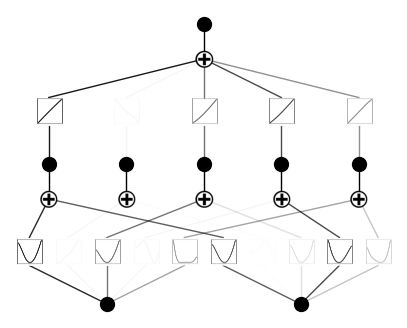

In [4]:
import torch
import numpy as np
from kan import KAN

# f(x1, x2) = x1^2 + x2^2
X = np.random.uniform(-2, 2, (600, 2))
y = (X[:, 0]**2 + X[:, 1]**2).reshape(-1, 1)

X = torch.FloatTensor(X)
y = torch.FloatTensor(y)

X_train, X_test = X[:500], X[500:]
y_train, y_test = y[:500], y[500:]

# 2 inputs, 5 hidden layers, 1 output
model = KAN(width=[2, 5, 1])

dataset = {
    'train_input': X_train, 
    'train_label': y_train,
    'test_input': X_test,
    'test_label': y_test
}
model.fit(dataset, steps=1000)

model.plot()
model.prune()
formula = model.symbolic_formula()
print(formula)

In [5]:
from src.newkan import NewKAN

model = NewKAN([2, 5, 1], grid_size=5, spline_order=3)

X = np.random.uniform(-1, 1, (100, 2))
y_true = X[:, 0]**2 + X[:, 1]**2

y_pred = model(X)

print(f"Input shape: {X.shape}")
print(f"Output shape: {y_pred.shape}")
print(f"Sample predictions: {y_pred[:5].flatten()}")
print(f"Sample true values: {y_true[:5]}")

Input shape: (100, 2)
Output shape: (100, 1)
Sample predictions: [-0.05267193 -0.07420491 -0.06513854 -0.08126172 -0.06929644]
Sample true values: [1.39824408 0.74026965 0.0641859  1.08840894 0.08290175]
